# Simple Neural Network Classifier in PyTorch

## Overview

In this exercise you will build, train, and evaluate a **binary classification neural network** using **PyTorch**.

The business context is **customer purchase intention**: given a user's browsing behaviour on an e-commerce site, predict whether they will complete a purchase during that session.

By the end of this notebook you will have practiced:
- Loading and preprocessing a real-world tabular dataset
- Encoding categorical features and normalising numerical ones
- Building a feedforward neural network with `torch.nn.Module`
- Writing a training loop with a loss function and optimiser
- Evaluating model performance with accuracy, precision, recall, and F1-score
- Visualising training progress


## Dataset: Online Shoppers Purchasing Intention

**Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset)

The dataset contains 12,330 sessions collected from an e-commerce website. Each row represents one user session and includes:

| Feature group | Examples |
|---|---|
| Page visit counts | `Administrative`, `Informational`, `ProductRelated` |
| Time spent on pages | `Administrative_Duration`, `Informational_Duration`, `ProductRelated_Duration` |
| Google Analytics metrics | `BounceRates`, `ExitRates`, `PageValues`, `SpecialDay` |
| Session context | `Month`, `OperatingSystems`, `Browser`, `Region`, `TrafficType` |
| Visitor type | `VisitorType` (Returning / New / Other) |
| Timing flag | `Weekend` (Boolean) |

**Target variable:** `Revenue` — `True` if the session ended in a purchase, `False` otherwise.

The dataset is **imbalanced**: roughly 84 % of sessions do not result in a purchase.

### Getting the data

Run the cell below to download the CSV directly from the UCI repository.

In [1]:
import urllib.request
import os

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
filename = "online_shoppers_intention.csv"

if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)
    print("Dataset downloaded.")
else:
    print("Dataset already present.")

Dataset downloaded.


## Step 1 — Imports

Import all libraries you will need for this exercise.

**You will need at minimum:**
- `pandas` and `numpy` for data handling
- `sklearn` utilities: `train_test_split`, `StandardScaler`, and classification metrics
- `torch`, `torch.nn`, `torch.optim`
- `torch.utils.data`: `TensorDataset`, `DataLoader`
- `matplotlib.pyplot` for plotting

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

## Step 2 — Load and Explore the Data

Load the CSV file into a pandas DataFrame.

**Tasks:**
1. Load the dataset and display the first few rows.
2. Check the shape, column names, and data types.
3. Check for missing values.
4. Inspect the class balance: how many sessions resulted in a purchase vs. not?


In [3]:
df = pd.read_csv("online_shoppers_intention.csv")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nColumn names: {df.columns.tolist()}")

   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0         0.0   Feb   

In [4]:
print("Missing values:\n", df.isnull().sum())
print(f"\nClass balance:")
print(df['Revenue'].value_counts())
print(f"\nClass proportions:")
print(df['Revenue'].value_counts(normalize=True))

Missing values:
 Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Class balance:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Class proportions:
Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


## Step 3 — Preprocess the Data

The dataset contains a mix of numerical and categorical columns. You need to prepare it before passing it to a neural network.

**Tasks:**
1. **Encode categorical columns.** The columns `Month`, `VisitorType`, and `Weekend` are not numeric. Use one-hot encoding (e.g., `pd.get_dummies`) or label encoding as appropriate. Drop the original columns after encoding.
2. **Encode the target.** Convert the `Revenue` column (boolean) to integer (0/1) and separate it from the features.
3. **Split the data** into training and test sets (80 % / 20 %). Use `random_state=42` and `stratify=y` to preserve class proportions.
4. **Normalise numerical features** using `StandardScaler`. Fit the scaler on the training set only, then transform both train and test sets.

> **Why stratify?** The dataset is imbalanced. Stratified splitting ensures both train and test sets have the same proportion of positive examples as the full dataset.

In [5]:
df_processed = df.copy()

# Encode categorical features
df_processed = pd.get_dummies(df_processed, columns=['Month', 'VisitorType'], drop_first=False)

# Convert boolean columns to int
df_processed['Weekend'] = df_processed['Weekend'].astype(int)
df_processed['Revenue'] = df_processed['Revenue'].astype(int)

# Separate features and target
X = df_processed.drop('Revenue', axis=1).values
y = df_processed['Revenue'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature matrix shape: (12330, 28)
Target shape: (12330,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training target distribution: {np.bincount(y_train)}")
print(f"Test target distribution: {np.bincount(y_test)}")

Training set shape: (9864, 28)
Test set shape: (2466, 28)
Training target distribution: [8338 1526]
Test target distribution: [2084  382]


## Step 4 — Create PyTorch Datasets and DataLoaders

PyTorch models consume data through `DataLoader` objects, which handle batching and shuffling automatically.

**Tasks:**
1. Convert your NumPy arrays `X_train`, `X_test`, `y_train`, `y_test` to `torch.FloatTensor` (features) and `torch.FloatTensor` (labels — keep as float for `BCELoss` compatibility).
2. Wrap each pair into a `TensorDataset`.
3. Create a `DataLoader` for the training set with `batch_size=64` and `shuffle=True`, and one for the test set with `shuffle=False`.
4. Print the number of batches in each loader to verify.

In [7]:
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Number of batches in training set: {len(train_loader)}")
print(f"Number of batches in test set: {len(test_loader)}")

Number of batches in training set: 155
Number of batches in test set: 39


## Step 5 — Define the Neural Network

Build a feedforward neural network by subclassing `torch.nn.Module`.

**Architecture requirements:**
- **Input layer:** size equal to the number of features after preprocessing.
- **Hidden layer 1:** 64 neurons, ReLU activation.
- **Hidden layer 2:** 32 neurons, ReLU activation.
- **Output layer:** 1 neuron, Sigmoid activation (outputs a probability between 0 and 1).

**Tasks:**
1. Define the class `CustomerClassifier(nn.Module)` with an `__init__` method that builds the layers and a `forward` method that defines the data flow.
2. Instantiate the model and print it to verify the architecture.

> **Tip:** `nn.Sequential` can help you chain layers cleanly inside `__init__`.

In [8]:
class CustomerClassifier(nn.Module):
    def __init__(self, input_size):
        super(CustomerClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

model = CustomerClassifier(input_size=X_train.shape[1])
print(model)

CustomerClassifier(
  (network): Sequential(
    (0): Linear(in_features=28, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## Step 6 — Define Loss Function and Optimiser

For binary classification with a sigmoid output, the standard choice is **Binary Cross-Entropy loss**.

**Tasks:**
1. Instantiate `nn.BCELoss()` as your loss function.
2. Instantiate `torch.optim.Adam` with a learning rate of `0.001` as your optimiser, passing `model.parameters()`.

> **Why Adam?** Adam adapts the learning rate per parameter and generally converges faster than plain SGD on tabular data.

In [9]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Step 7 — Write the Training Loop

Train the model for **30 epochs**. For each epoch you should:

1. Set the model to training mode with `model.train()`.
2. Iterate over batches from `train_loader`.
3. For each batch:
   - Zero the gradients with `optimizer.zero_grad()`.
   - Run a **forward pass** to get predictions.
   - Compute the **loss**.
   - Run a **backward pass** with `loss.backward()`.
   - Update the weights with `optimizer.step()`.
4. After all batches, record the average epoch training loss.
5. Run a **validation pass** (no gradient computation) over `test_loader` and record the average test loss.
6. Print the losses every 5 epochs.

Store training and test losses in lists so you can plot them in the next step.

In [10]:
num_epochs = 30
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)
    
    # Validation phase
    model.eval()
    epoch_test_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            epoch_test_loss += loss.item()
    
    epoch_test_loss /= len(test_loader)
    test_losses.append(epoch_test_loss)
    
    # Print every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_train_loss:.4f}, Test Loss: {epoch_test_loss:.4f}")

Epoch [5/30] - Train Loss: 0.2368, Test Loss: 0.2597
Epoch [10/30] - Train Loss: 0.2239, Test Loss: 0.2522
Epoch [15/30] - Train Loss: 0.2136, Test Loss: 0.2582
Epoch [20/30] - Train Loss: 0.2041, Test Loss: 0.2586
Epoch [25/30] - Train Loss: 0.1961, Test Loss: 0.2638
Epoch [30/30] - Train Loss: 0.1899, Test Loss: 0.2657


## Step 8 — Visualise Training Progress

Plot the training and test loss curves over epochs.

**Tasks:**
1. Create a line plot with epochs on the x-axis and loss on the y-axis.
2. Show both training loss and test loss on the same plot with a legend.
3. Add axis labels and a title.

> **What to look for:** If training loss decreases but test loss plateaus or rises, the model may be overfitting.

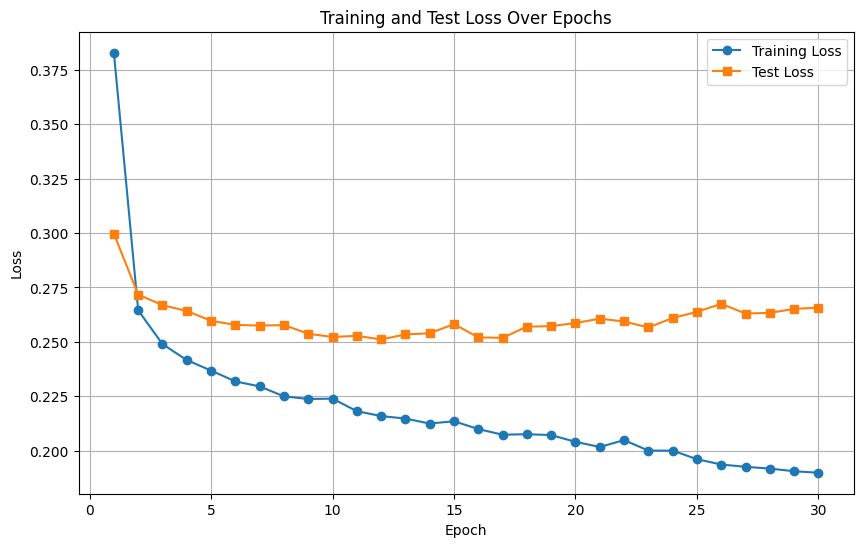

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, num_epochs + 1), test_losses, label='Test Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## Step 9 — Evaluate the Model

A single accuracy number is not enough for an imbalanced dataset. Evaluate using a full set of metrics.

**Tasks:**
1. Set the model to evaluation mode with `model.eval()`.
2. Run inference over the entire test set (disable gradient tracking with `torch.no_grad()`).
3. Convert predicted probabilities to binary labels using a threshold of 0.5.
4. Compute and print:
   - **Accuracy**
   - **Precision**
   - **Recall**
   - **F1-score**
5. Print a **classification report** using `sklearn.metrics.classification_report`.

> **Tip:** Use `sklearn.metrics` functions. Remember to move tensors to CPU and convert to NumPy before passing to sklearn.

In [12]:
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        predictions = model(X_batch)
        all_predictions.append(predictions.numpy())
        all_targets.append(y_batch.numpy())

all_predictions = np.vstack(all_predictions)
all_targets = np.vstack(all_targets)

# Convert to binary labels using threshold 0.5
y_pred_binary = (all_predictions >= 0.5).astype(int).flatten()
y_test_binary = all_targets.flatten().astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test_binary, y_pred_binary)
precision = precision_score(y_test_binary, y_pred_binary)
recall = recall_score(y_test_binary, y_pred_binary)
f1 = f1_score(y_test_binary, y_pred_binary)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_binary, target_names=['No Purchase', 'Purchase']))

Accuracy: 0.8917
Precision: 0.6758
Recall: 0.5785
F1-score: 0.6234

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.92      0.95      0.94      2084
    Purchase       0.68      0.58      0.62       382

    accuracy                           0.89      2466
   macro avg       0.80      0.76      0.78      2466
weighted avg       0.89      0.89      0.89      2466

